<center>
    <img src="https://digip.unibg.it/sites/dip3/files/logo-dip-it.svg">
    <h1><b>Previsione del K/D Ratio in Valorant</b> - AA 2025/2026</h1>
    <h2>🗾 Gruppo Hayabusa 🗾​</h2>
    <h3>Spampatti Nicolò, Piffari Matteo, Ghilardi Giovanni, Magri Marco</h3>
</center>

# Presentazione del dataset

Il dataset oggetto di analisi raccoglie statistiche dettagliate relative al VCT 2024. I dati offrono un livello di dettaglio elevato, permettendo di analizzare le performance dei singoli pro player non solo a livello di match complessivo, ma scendendo nel dettaglio delle singole mappe, agenti e delle fasi di gioco, oltre alle metriche standard di rendimento (K/D, ACS, ADR).

## Obiettivo

Capire quali fattori tecnici e tattici prevedono un K/D elevato.

# Importazione delle librerie

In [1]:
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats
from tabulate import tabulate
from statsmodels.formula.api import ols
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.model_selection import train_test_split
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Importazione dei dati

In [2]:
# importazione del dataset
data = pl.read_csv(
    source = "valorant.csv",
    encoding = "latin-1",
    truncate_ragged_lines = True
)

# visualizzazione dei nomi delle colonne
print("Colonne disponibili nel dataset:")
print(data.columns)

Colonne disponibili nel dataset:
['Tournament;Stage;Match.Type;Match.Name;Map;Player.Team;Player;Enemy.Team;Enemy;Player.Kills;Enemy.Kills;Difference;Kill.Type;Agents;Rating;Average.Combat.Score;Kills;Deaths;Assists;Kills...Deaths..KD.;Kill..Assist..Trade..Survive..;Average.Damage.Per.Round;Headshot..;First.Kills;First.Deaths;Kills...Deaths..FKD.;Side;Team.B;Team.A.Score;Team.B.Score;Match.Result;Elimination;Detonated;Defused;Time.Expiry..No.Plant.;Eliminated;Defused.Failed;Detonation.Denied;Time.Expiry..Failed.to.Plant.;RESTO']


In [ ]:
# importazione del dataset
data = pl.read_csv(
    source = "valorant.csv",
    encoding = "latin-1",
    truncate_ragged_lines = True,
    separator = ";"
)

data = data.rename({
    "Player.Team": "Player Team",
    "Team.B": "Enemy Team",
    "Average.Combat.Score": "Average Combat Score",
    "Kills...Deaths..KD.":"KD",
    "Defused.Failed": "Defused Failed",
    "Detonation.Denied": "Detonation Denied",
    "Match.Result": "Match Result",
    "Average.Damage.Per.Round": "Avg Damage Per Round",
    "Headshot.." : "Headshot"
})

categorical_columns = [
    "Match.Type",
    "Map",
    "Kill.Type",
    "Player Team",
    "Player",
    "Role",
    "Enemy Team",
    "Tournament"
]
numeric_columns = [
    "Rating",
    "Average Combat Score",
    "Kills",
    "Deaths",
    "Assists",
    "KD",
    "Avg Damage Per Round",
    "Headshot",
    "First.Kills",
    "First.Deaths",
    "Elimination",
    "Detonated",
    "Defused",
    "Defused Failed",
    "Detonation Denied", 
    "Match Result"
]

data = data.drop(
    "Enemy",
    "Player.Kills",
    "Enemy.Kills",
    "Difference",
    "Enemy.Team",
    "Side",
    "Team.A.Score",
    "Team.B.Score",
    "Time.Expiry..Failed.to.Plant.",
    "Time.Expiry..No.Plant.",
    "Kill..Assist..Trade..Survive..",
    "Stage",
    "Match.Name",
    "Kills...Deaths..FKD.",
    "Eliminated"
)

data = data.with_columns(
    pl.when(pl.col("Match Result").str.contains(pl.col("Player Team")))
    .then(1)
    .otherwise(0)
    .cast(pl.Int64)
    .alias("Match Result")
)

float_expressions = [
    pl.col(col).cast(pl.String).str.replace(",", ".").cast(pl.Float64).alias(col)
    for col in numeric_columns if col in data.columns
]

data = data.with_columns(float_expressions)

agent_roles = {
    # duelists
    'jett': 'duelist', 'raze': 'duelist', 'reyna': 'duelist', 
    'phoenix': 'duelist', 'yoru': 'duelist', 'neon': 'duelist', 'iso': 'duelist',
    # initiators
    'sova': 'initiator', 'breach': 'initiator', 'skye': 'initiator', 
    'kayo': 'initiator', 'fade': 'initiator', 'gekko': 'initiator',
    # controllers
    'omen': 'controller', 'brimstone': 'controller', 'viper': 'controller', 
    'astra': 'controller', 'harbor': 'controller', 'clove': 'controller',
    # sentinels
    'sage': 'sentinel', 'cypher': 'sentinel', 'killjoy': 'sentinel', 
    'chamber': 'sentinel', 'deadlock': 'sentinel', 'vyse': 'sentinel'
}

data = data.with_columns(
    pl.col("Agents").replace(agent_roles).alias("Role")
)

# Visualizzazione
print(data.head(10))


shape: (10, 26)
┌─────────────┬─────────────┬────────┬─────────────┬───┬─────────┬────────────┬───────┬────────────┐
│ Tournament  ┆ Match.Type  ┆ Map    ┆ Player Team ┆ … ┆ Defused ┆ Detonation ┆ RESTO ┆ Role       │
│ ---         ┆ ---         ┆ ---    ┆ ---         ┆   ┆ Failed  ┆ Denied     ┆ ---   ┆ ---        │
│ str         ┆ str         ┆ str    ┆ str         ┆   ┆ ---     ┆ ---        ┆ i64   ┆ str        │
│             ┆             ┆        ┆             ┆   ┆ f64     ┆ f64        ┆       ┆            │
╞═════════════╪═════════════╪════════╪═════════════╪═══╪═════════╪════════════╪═══════╪════════════╡
│ Valorant    ┆ Upper Quart ┆ Icebox ┆ G2 Esports  ┆ … ┆ 1.0     ┆ 4.0        ┆ 0     ┆ initiator  │
│ Champions   ┆ erfinals    ┆        ┆             ┆   ┆         ┆            ┆       ┆            │
│ 2024        ┆             ┆        ┆             ┆   ┆         ┆            ┆       ┆            │
│ Valorant    ┆ Upper Quart ┆ Icebox ┆ G2 Esports  ┆ … ┆ 1.0     ┆ 4.0     

# EDA (Exploratory Data Analysis)

## Distribuzione delle variabili numeriche e correlogramma
Valuto le statistiche (media, sd, varianza) e la distribuzione, analisi preliminare

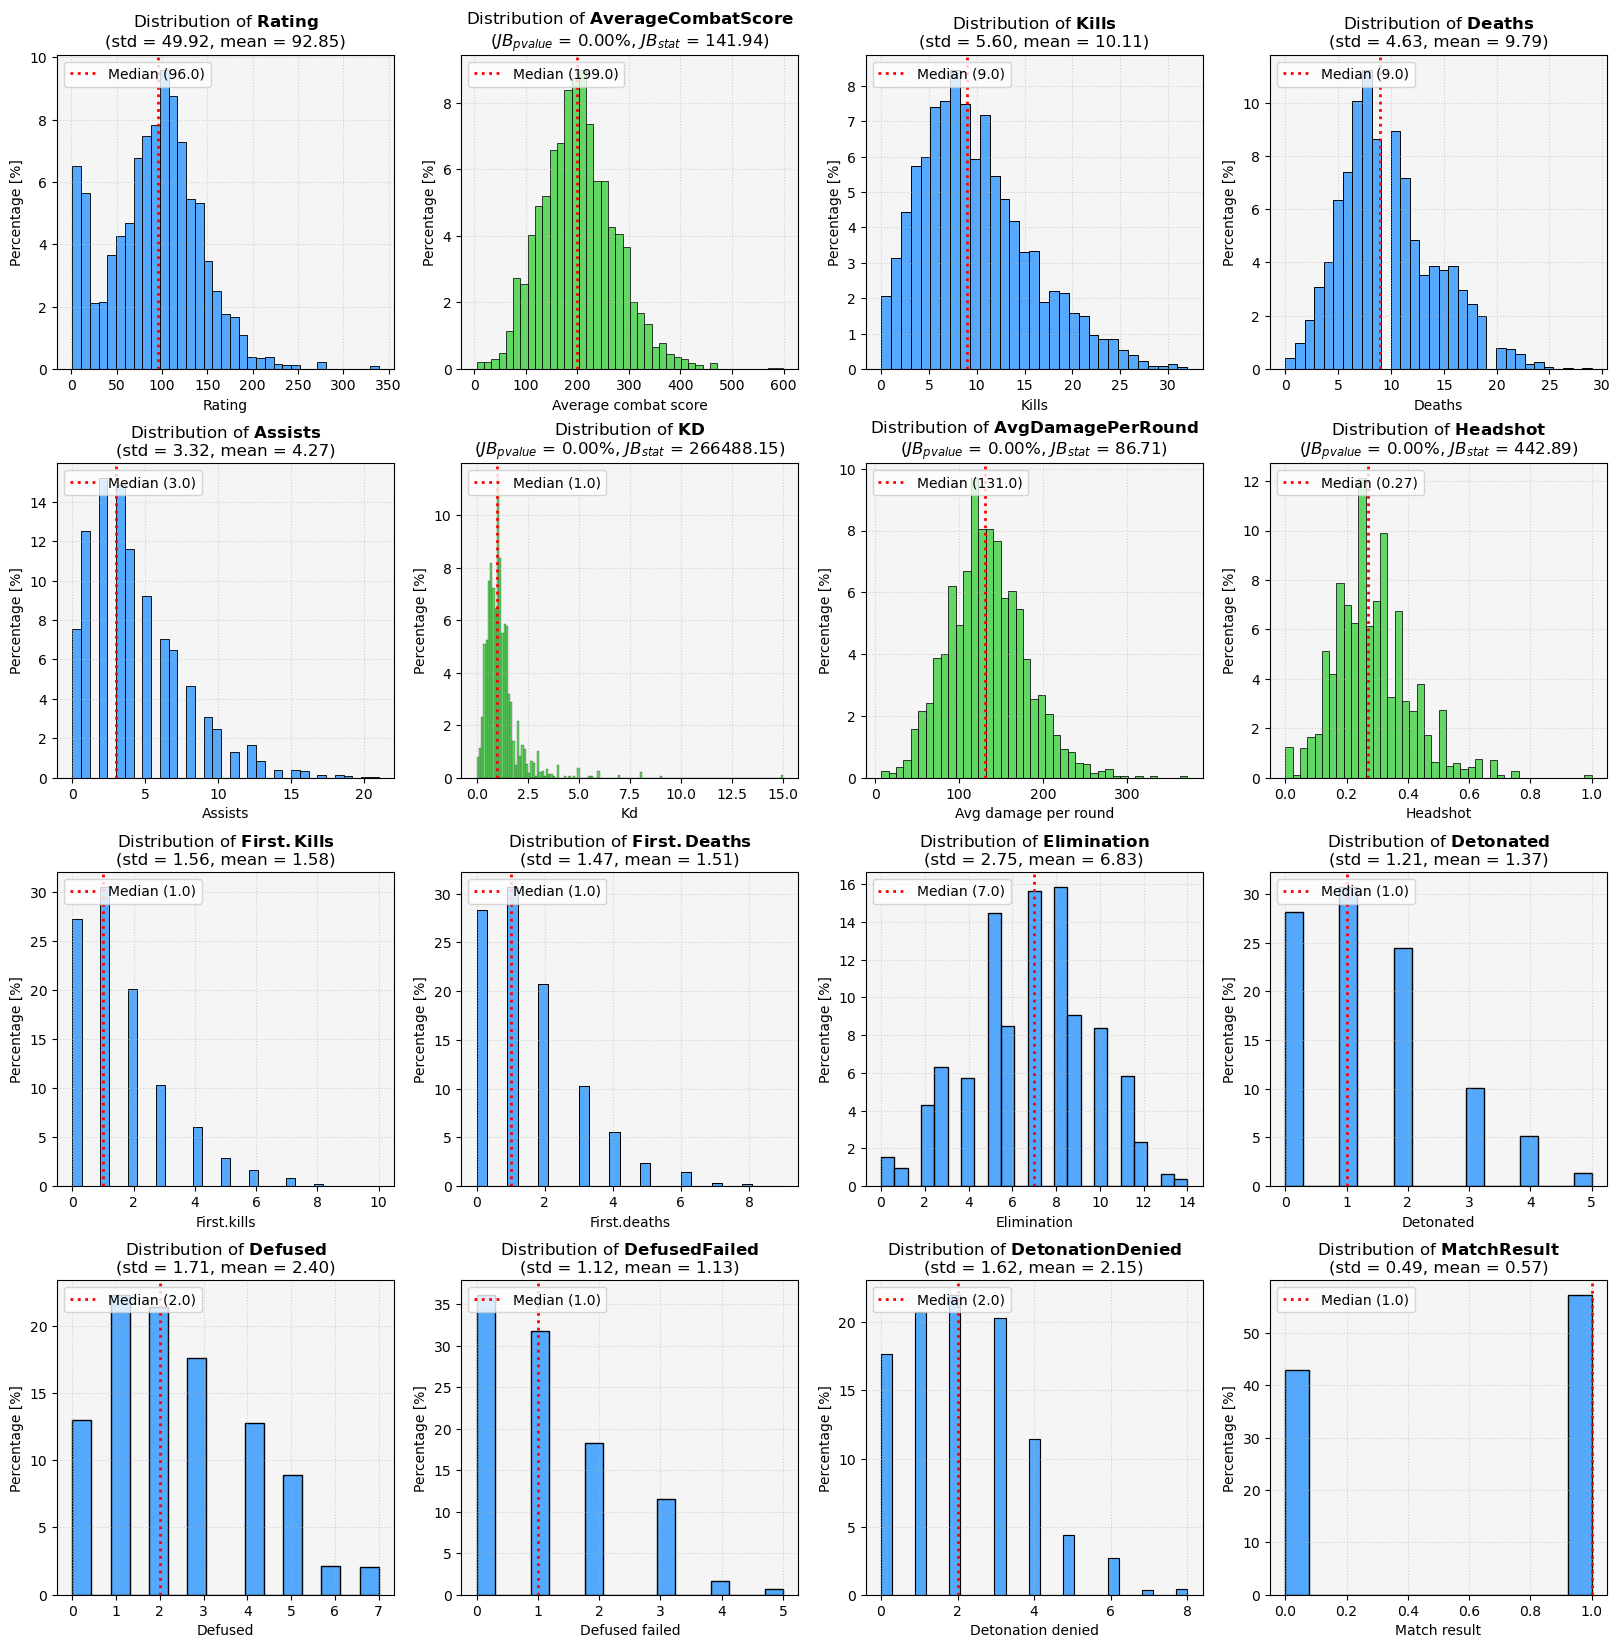

In [4]:
# layout
ncols = 4
nrows = 4
fig, axes = plt.subplots(
    nrows = nrows,
    ncols = ncols,
    figsize=(20, nrows * 5)
)
fig.subplots_adjust(
    hspace = .3,
    wspace = .2
)
axes = axes.flatten()

normTest = ["Average Combat Score", "KD", "Avg Damage Per Round", "Headshot"]

for i, variable_i in enumerate(numeric_columns):
    var_name = variable_i.replace('_', ' \\ ')

    sns.histplot(
        data = data.to_pandas(),
        x = variable_i,
        stat = "percent",
        color = "limegreen" if variable_i in normTest else "dodgerblue",
        ax = axes[i]
    )
    median_i = data[variable_i].median()
    axes[i].axvline(
        median_i,
        color = "red",
        ls = ":",
        lw = 2,
        label = f"Median ({median_i})"
    )
    axes[i].set(
        xlabel = variable_i.capitalize().replace("_", " "),
        ylabel = "Percentage [%]",
        facecolor = "whitesmoke"
    )
    axes[i].grid(
        ls = ":",
        alpha = .5
    )
    axes[i].legend(
        loc = "upper left"
    )

    # test di normalità di Jarque-Bera
    if variable_i in normTest:
        statistic, p_value = stats.jarque_bera(data[variable_i].to_list())
        axes[i].set_title(
            f"Distribution of $\\mathbf{{{var_name}}}$" +
            f"\n($JB_{{pvalue}}$ = {p_value*100:.2f}%, $JB_{{stat}}$ = {statistic:.2f})",
            fontsize = 12
        )
    else:
        axes[i].set_title(
            f"Distribution of $\\mathbf{{{var_name}}}$" +
            f"\n(std = {data[variable_i].std():.2f}, mean = {data[variable_i].mean():.2f})",
            fontsize = 12
        )


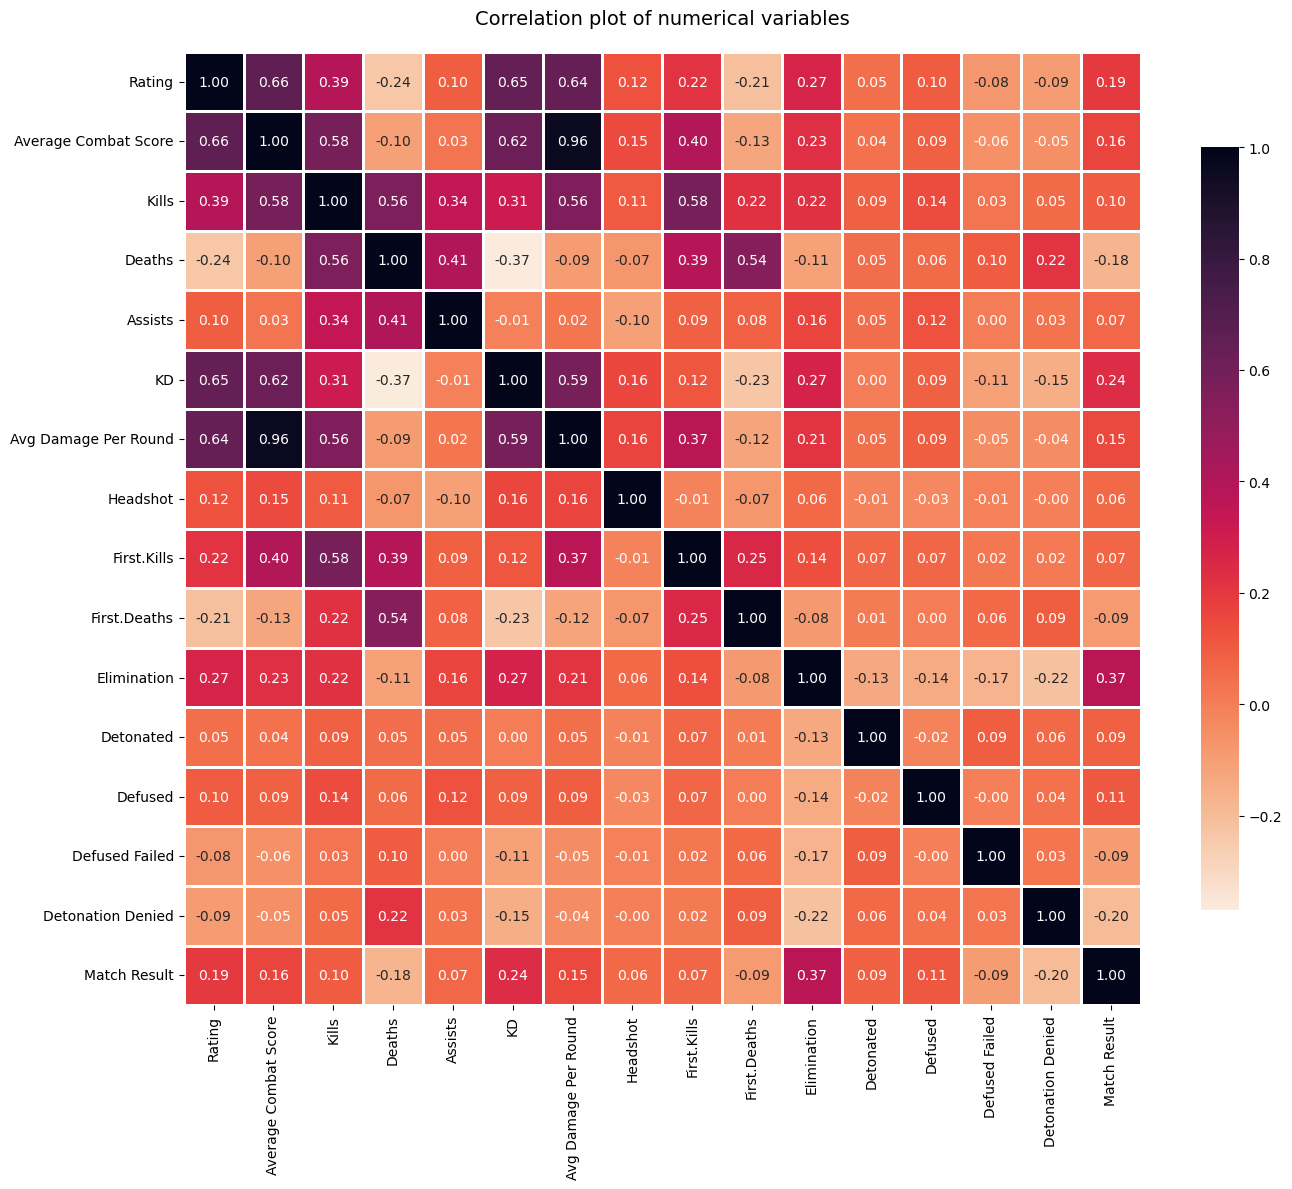

In [5]:
fig, ax = plt.subplots(figsize=(14, 12))

corr = data[numeric_columns].to_pandas().corr()
sns.heatmap(
    data = corr,
    annot = True,
    fmt = ".2f",
    cmap = "rocket_r",
    linewidths = 1,
    cbar_kws = {"shrink": 0.8},
    ax = ax
)
ax.tick_params(
    "y",
    rotation = 0
)
ax.set_title(
    "Correlation plot of numerical variables",
    size = 14,
    pad = 20
)
plt.tight_layout()

## Legami tra le variabili numeriche e la variabile target

### Variabili numeriche per il KD

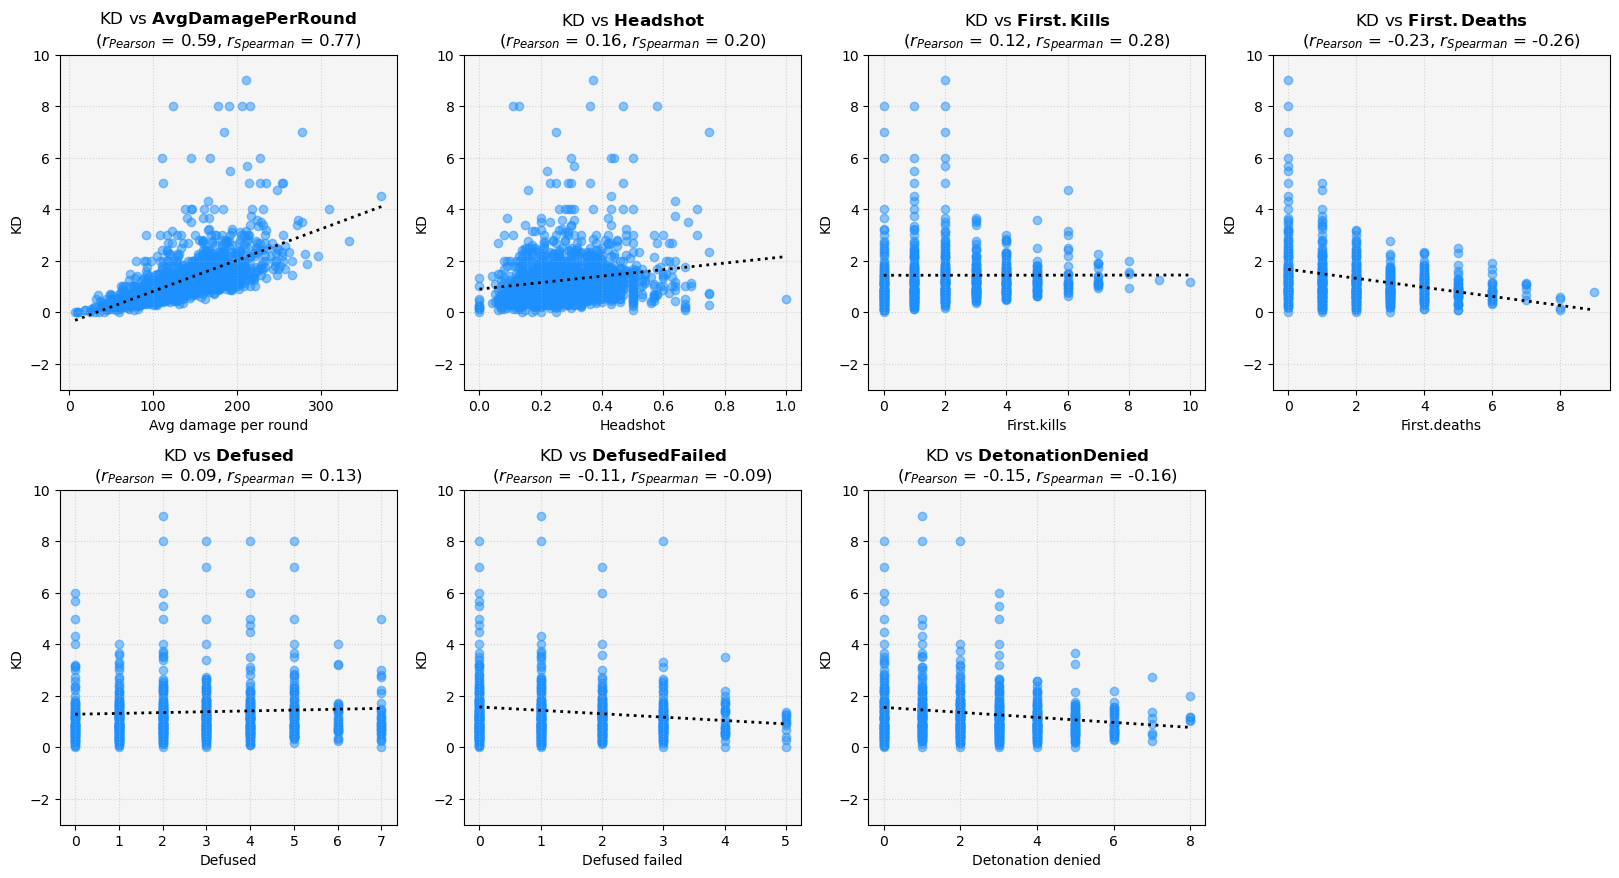

In [6]:
numeric_KD_columns = ["Avg Damage Per Round", "Headshot", "First.Kills", "First.Deaths", "Defused", "Defused Failed", "Detonation Denied"]

ncols = 4
nrows = 2
fig, axes = plt.subplots(
    nrows = nrows,
    ncols = ncols,
    figsize=(20, nrows * 5)
)
fig.subplots_adjust(
    hspace = .3,
    wspace = .2
)
axes = axes.flatten()

for i, variable_i in enumerate(numeric_KD_columns):
    sns.regplot(
        data = data.unique(
            subset = [variable_i, "KD"]
        ),
        x = variable_i,
        y = "KD",
        scatter_kws = {
            "color": "dodgerblue",
            "alpha": .5
        },
        line_kws = {
            "color": "black",
            "ls": ":",
            "lw": 2
        },
        ci = None,
        ax = axes[i]
    )
    axes[i].set(
        xlabel = variable_i.capitalize().replace("_", " "),
        ylim = (-3, 10),
        ylabel = "KD",
        facecolor = "whitesmoke"
    )
    axes[i].grid(
        ls = ":",
        alpha = .5
    )

    r_pearson = stats.pearsonr(data[variable_i].to_list(), data["KD"].to_list())
    r_spearman = stats.spearmanr(data[variable_i].to_list(), data["KD"].to_list())
    axes[i].set_title(
        f"KD vs $\\mathbf{{{variable_i}}}$"
        + f"\n($r_{{Pearson}}$ = {r_pearson[0]:.2f}, $r_{{Spearman}}$ = {r_spearman.correlation:.2f})",
        fontsize = 12
    )

# rimozione delle figure vuote
for j in range(i + 1, nrows * ncols):
    fig.delaxes(axes[j])

### BoxPlot

C:\Users\Spampa\AppData\Local\Temp\ipykernel_11780\731183529.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


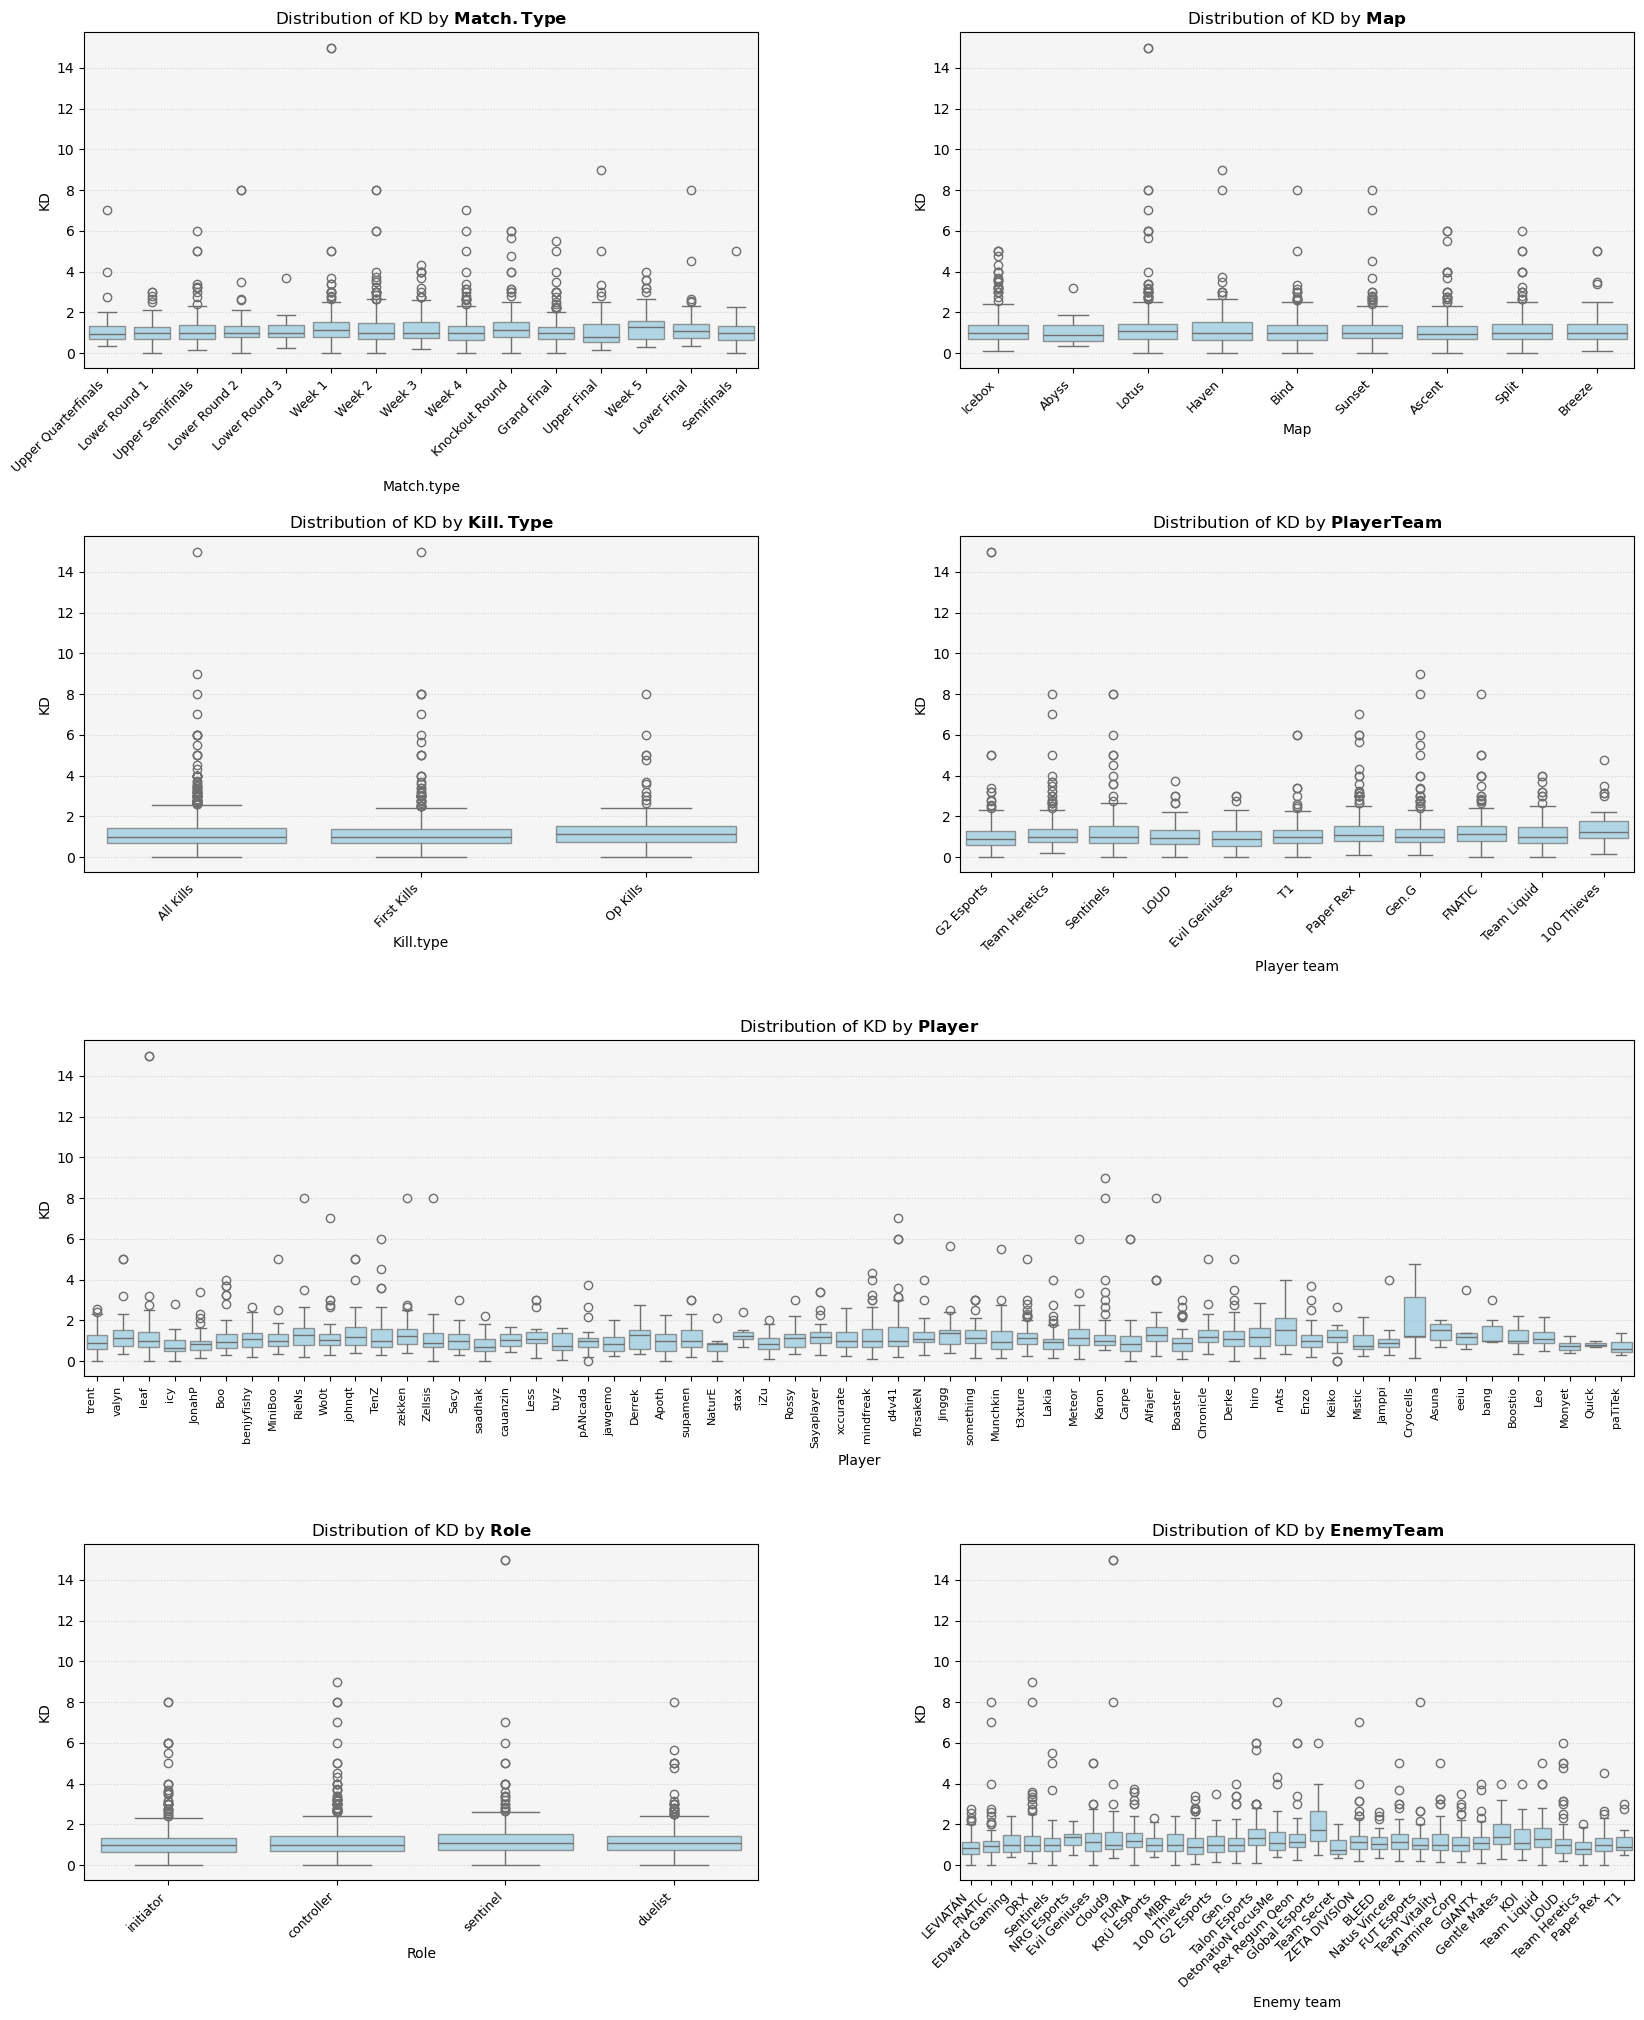

In [7]:
# layout per boxplot delle variabili categoriche
ncols = 2
nrows = 4
fig = plt.figure(figsize=(20, nrows * 6))
gs = fig.add_gridspec(nrows, ncols, hspace=0.5, wspace=0.3)

subplot_idx = 0

for i, variable_i in enumerate(categorical_columns):
    if variable_i == "Player":
        if subplot_idx % ncols != 0:
            subplot_idx += 1
            
        current_row = subplot_idx // ncols
        if current_row < nrows:
            ax = fig.add_subplot(gs[current_row, :])
            subplot_idx += 2
        else: continue
    else:
        current_row = subplot_idx // ncols
        current_col = subplot_idx % ncols
        if current_row < nrows:
            ax = fig.add_subplot(gs[current_row, current_col]) 
            subplot_idx += 1
        else: continue

    # --- BOXPLOT ---
    sns.boxplot(
        data = data.to_pandas(),
        x = variable_i,
        y = "KD",
        color = "skyblue",
        boxprops = dict(alpha=0.7),
        ax = ax
    )
    
    # --- labels ---
    ax.set(
        xlabel = variable_i.capitalize().replace("_", " "),
        ylabel = "KD",
        facecolor = "whitesmoke"
    )
    ax.grid(
        ls = ":",
        alpha = .5,
        axis = 'y'
    )
    ax.set_title(
        f"Distribution of KD by $\\mathbf{{{variable_i}}}$",
        fontsize = 12
    )
    
    if variable_i == "Player":
        ax.tick_params(axis='x', rotation=90, labelsize=8)
    else:
        ax.tick_params(axis='x', rotation=45, labelsize=9)
        
    plt.setp(ax.get_xticklabels(), ha='right')

plt.tight_layout()
plt.show()

### Conclusioni
Non si nota un grande legame tra First Kills e KD, (Stimatore ha un p-value di 0.50)

In [8]:
numeric_KD_columns.remove("First.Kills")

## Distribuzione delle variabili categoriche

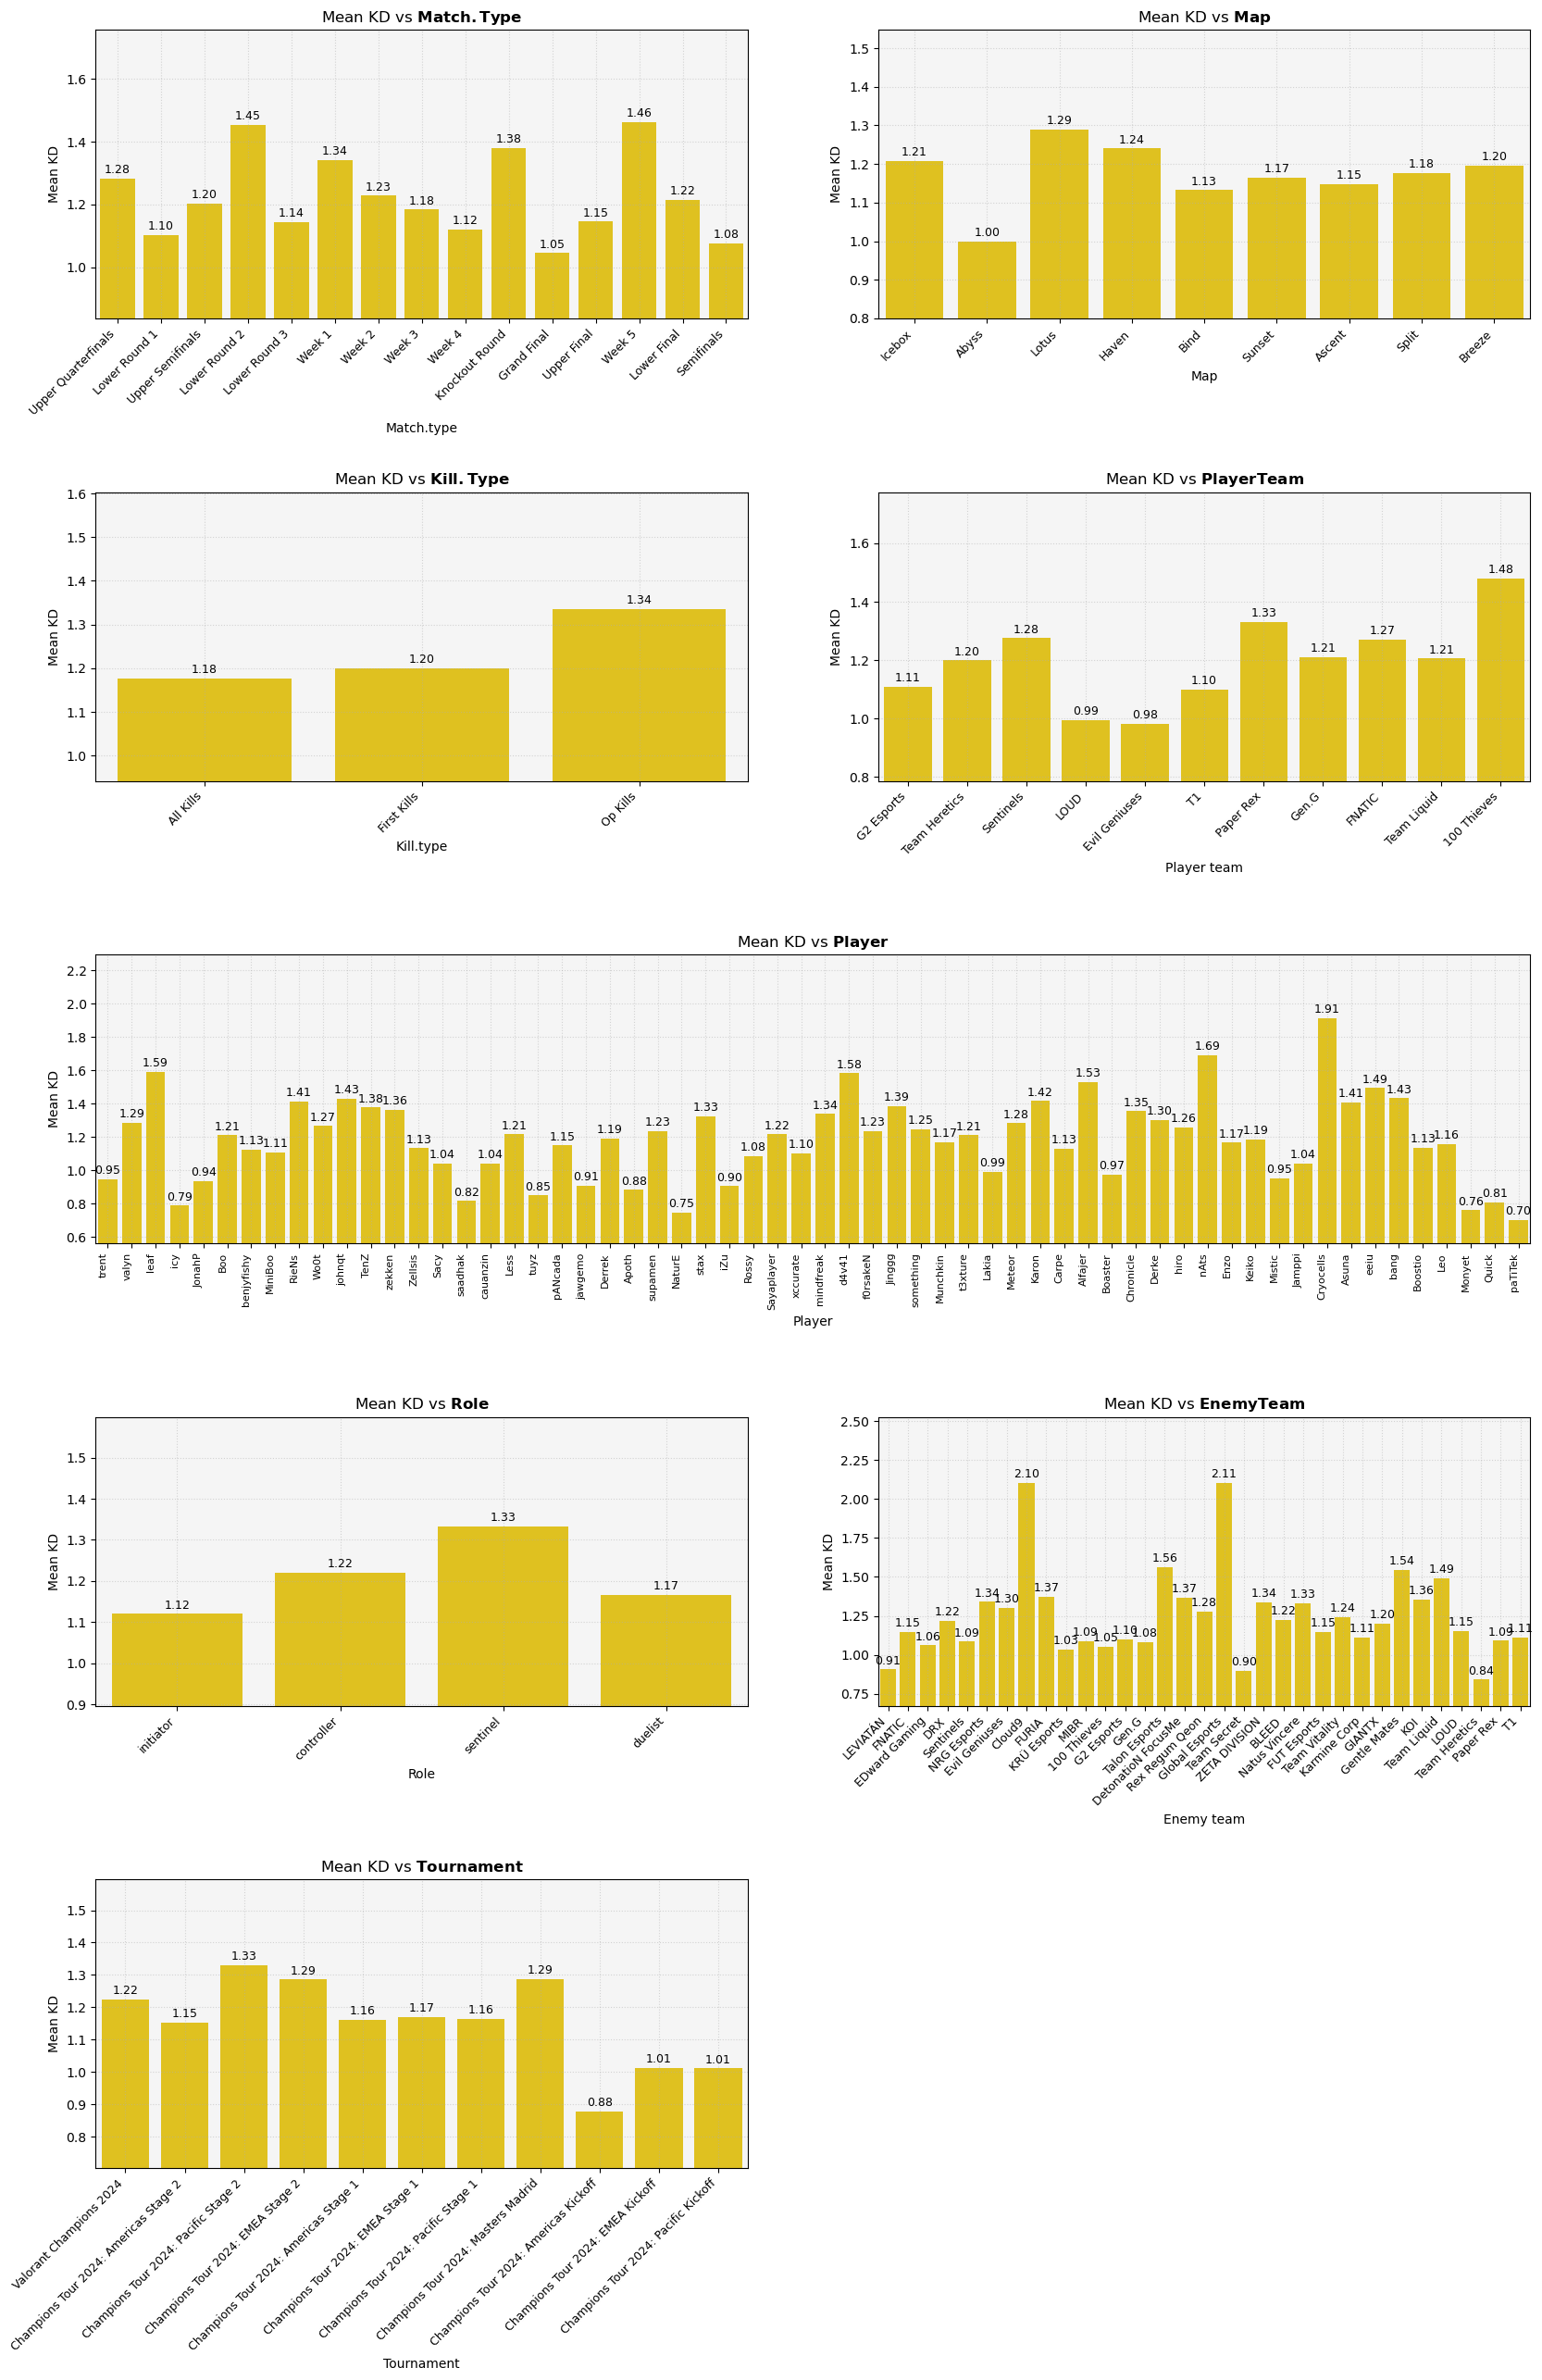

In [ ]:
ncols = 2
nrows = 5
fig = plt.figure(figsize=(20, nrows * 6))
gs = fig.add_gridspec(nrows, ncols, hspace=0.6, wspace=0.2)

subplot_idx = 0

for i, variable_i in enumerate(categorical_columns):
    stat_type = "Mean"
    est_func = "mean"      
    kd_stats = data.group_by(variable_i).agg(pl.col("KD").mean())["KD"]
    
    max_kd = kd_stats.max()
    min_kd = kd_stats.min()

    if variable_i == "Player":
        if subplot_idx % ncols != 0:
            subplot_idx += 1
            
        current_row = subplot_idx // ncols
        if current_row < nrows:
            ax = fig.add_subplot(gs[current_row, :])
            subplot_idx += 2
        else: continue
    else:
        current_row = subplot_idx // ncols
        current_col = subplot_idx % ncols
        if current_row < nrows:
            ax = fig.add_subplot(gs[current_row, current_col])
            subplot_idx += 1
        else: continue

    sns.barplot(
        data = data,
        x = variable_i,
        y = "KD",
        estimator = est_func,  # <--- Qui passa np.median o "mean"
        color = "gold",
        errorbar = None,
        ax = ax
    )
    
    # --- labels ---
    ax.set(
        xlabel = variable_i.capitalize().replace("_", " "),
        ylim = (min_kd * 1.20 - 0.5 if min_kd < 0 else min_kd * 0.8, max_kd * 1.20),
        ylabel = f"{stat_type} KD",  # <--- Aggiorna asse Y (Median KD / Mean KD)
        facecolor = "whitesmoke",
    )
    ax.grid(ls = ":", alpha = .5)
    
    ax.bar_label(
        ax.containers[0],
        fontsize = 9,
        label_type = "edge",
        fmt = "%.2f",
        padding = 2
    )
    
    # Title
    ax.set_title(f"{stat_type} KD vs $\\mathbf{{{variable_i}}}$", fontsize = 12)
    
    if variable_i == "Player":
        ax.tick_params(axis='x', rotation=90, labelsize=8)
    else:
        ax.tick_params(axis='x', rotation=45, labelsize=9)
        
    plt.setp(ax.get_xticklabels(), ha='right')

plt.show()

## Test ANOVA per selezionare le variabili categoriche più significative

In [ ]:
ANOVA_results = []
for variable_i in categorical_columns:

    ANOVA_table = sm.stats.anova_lm(
        ols(
            formula = f"KD ~ C(Q('{variable_i}'))",
            data = data.to_pandas()
        ).fit(),
        typ = 2
    )
    ANOVA_results.append(
        (variable_i, ANOVA_table.loc[f"C(Q('{variable_i}'))", "PR(>F)"])
    )

print(
    tabulate(
        tabular_data = ANOVA_results,
        headers = ["Categorical variable", "ANOVA p-value"],
        tablefmt = "pretty",
        colalign = ["center"] * 2
    )
)

+----------------------+------------------------+
| Categorical variable |     ANOVA p-value      |
+----------------------+------------------------+
|      Match.Type      |  0.006831994130515835  |
|         Map          |   0.2773563848531473   |
|      Kill.Type       |  0.15165106019025915   |
|     Player Team      | 0.0017687763174567656  |
|        Player        |  9.17718617749506e-06  |
|         Role         |  0.004800597266641189  |
|      Enemy Team      | 1.5787190033857463e-11 |
|      Tournament      |  0.012695140102298389  |
+----------------------+------------------------+


# Stima del modello
Modello Regressione Log-Lineare (Poisson)

In [ ]:
numeric_vars = " + ".join([f"Q('{col}')" if " " in col or "." in col else col for col in numeric_KD_columns])

# suddivisione del dataset in train e test set
train_data, test_data = train_test_split(
    data,
    test_size = .3,
    random_state = 42
)

# stima
mhat_kd = ols(
    formula = f"np.log(KD + 1) ~ {numeric_vars} + C(Role) + C(Q('Enemy Team')) + C(Q('Player Team')) + C(Q('Match.Type'))", # Applico il logaritmo del KD modello con soli valori positivi, il + 1 è per non vavere log di 0
    data = train_data.to_pandas()
).fit()
mhat_kd.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         np.log(KD + 1)   R-squared:                       0.624
Model:                            OLS   Adj. R-squared:                  0.608
Method:                 Least Squares   F-statistic:                     38.89
Date:                Tue, 13 Jan 2026   Prob (F-statistic):          2.78e-274
Time:                        16:06:43   Log-Likelihood:                 364.80
No. Observations:                1589   AIC:                            -597.6
Df Residuals:                    1523   BIC:                            -243.1
Df Model:                          65                                         
Covariance Type:            nonrobust                                         
=============================================================================================================
                                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                     0.0810      0.068      1.192      0.233      -0.052       0.214
C(Role)[T.duelist]                           -0.0694      0.015     -4.660      0.000      -0.099      -0.040
C(Role)[T.initiator]                         -0.0173      0.013     -1.341      0.180      -0.043       0.008
C(Role)[T.sentinel]                           0.0049      0.016      0.308      0.758      -0.026       0.036
C(Q('Enemy Team'))[T.BLEED]                   0.1448      0.069      2.110      0.035       0.010       0.279
C(Q('Enemy Team'))[T.Cloud9]                  0.2147      0.050      4.255      0.000       0.116       0.314
C(Q('Enemy Team'))[T.DRX]                     0.0731      0.046      1.601      0.110      -0.016       0.163
C(Q('Enemy Team'))[T.DetonatioN FocusMe]      0.1089      0.054      2.001      0.046       0.002       0.216
C(Q('Enemy Team'))[T.EDward Gaming]          -0.0806      0.068     -1.192      0.234      -0.213       0.052
C(Q('Enemy Team'))[T.Evil Geniuses]           0.0211      0.040      0.526      0.599      -0.058       0.100
C(Q('Enemy Team'))[T.FNATIC]                  0.0986      0.046      2.124      0.034       0.008       0.190
C(Q('Enemy Team'))[T.FURIA]                   0.1535      0.040      3.853      0.000       0.075       0.232
C(Q('Enemy Team'))[T.FUT Esports]             0.0502      0.059      0.856      0.392      -0.065       0.165
C(Q('Enemy Team'))[T.G2 Esports]              0.0893      0.061      1.470      0.142      -0.030       0.208
C(Q('Enemy Team'))[T.GIANTX]                  0.1231      0.060      2.044      0.041       0.005       0.241
C(Q('Enemy Team'))[T.Gen.G]                   0.0161      0.052      0.310      0.757      -0.086       0.118
C(Q('Enemy Team'))[T.Gentle Mates]            0.1929      0.064      2.998      0.003       0.067       0.319
C(Q('Enemy Team'))[T.Global Esports]          0.2614      0.078      3.351      0.001       0.108       0.414
C(Q('Enemy Team'))[T.KOI]                     0.1394      0.066      2.127      0.034       0.011       0.268
C(Q('Enemy Team'))[T.KRÜ Esports]             0.0347      0.053      0.656      0.512      -0.069       0.139
C(Q('Enemy Team'))[T.Karmine Corp]            0.0926      0.058      1.601      0.110      -0.021       0.206
C(Q('Enemy Team'))[T.LEVIATÁN]                0.0359      0.033      1.071      0.284      -0.030       0.102
C(Q('Enemy Team'))[T.LOUD]                    0.1055      0.039      2.735      0.006       0.030       0.181
C(Q('Enemy Team'))[T.MIBR]                    0.0776      0.039      1.976      0.048       0.001       0.155
C(Q('Enemy Team'))[T.NRG Esports]             0.0922      0.066      1.401      0.161      -0.037       0.221
C(Q

## Con dati standardizzati

In [12]:
numeric_vars = " + ".join([f"Q('{col}')" if " " in col or "." in col else col for col in numeric_KD_columns])

# standardizzazione dei dati
std_data = data.clone()
std_data[numeric_KD_columns] = StandardScaler().fit_transform(
    data.select(numeric_KD_columns)
)

# stima
mhat_kd_standard = ols(
    formula = f"np.log(KD + 1) ~ {numeric_vars} + C(Role) + C(Tournament) + C(Q('Enemy Team')) + C(Q('Player Team')) + C(Q('Match.Type'))",
    data = std_data.to_pandas()
).fit()
mhat_kd_standard.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         np.log(KD + 1)   R-squared:                       0.626
Model:                            OLS   Adj. R-squared:                  0.614
Method:                 Least Squares   F-statistic:                     49.03
Date:                Tue, 13 Jan 2026   Prob (F-statistic):               0.00
Time:                        16:06:43   Log-Likelihood:                 533.30
No. Observations:                2270   AIC:                            -914.6
Df Residuals:                    2194   BIC:                            -479.3
Df Model:                          75                                         
Covariance Type:            nonrobust                                         
==========================================================================================================================
                                                             coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------
Intercept                                                  0.6640      0.109      6.082      0.000       0.450       0.878
C(Role)[T.duelist]                                        -0.0718      0.012     -5.916      0.000      -0.096      -0.048
C(Role)[T.initiator]                                      -0.0283      0.011     -2.638      0.008      -0.049      -0.007
C(Role)[T.sentinel]                                       -0.0034      0.013     -0.266      0.790      -0.029       0.022
C(Tournament)[T.Champions Tour 2024: Americas Stage 1]     0.1131      0.077      1.461      0.144      -0.039       0.265
C(Tournament)[T.Champions Tour 2024: Americas Stage 2]     0.1176      0.067      1.762      0.078      -0.013       0.249
C(Tournament)[T.Champions Tour 2024: EMEA Kickoff]        -0.0382      0.127     -0.301      0.763      -0.287       0.210
C(Tournament)[T.Champions Tour 2024: EMEA Stage 1]        -0.0178      0.106     -0.169      0.866      -0.225       0.189
C(Tournament)[T.Champions Tour 2024: EMEA Stage 2]         0.0536      0.113      0.473      0.636      -0.168       0.276
C(Tournament)[T.Champions Tour 2024: Masters Madrid]       0.1565      0.065      2.421      0.016       0.030       0.283
C(Tournament)[T.Champions Tour 2024: Pacific Kickoff]      0.1399      0.090      1.558      0.119      -0.036       0.316
C(Tournament)[T.Champions Tour 2024: Pacific Stage 1]      0.1839      0.092      2.009      0.045       0.004       0.363
C(Tournament)[T.Champions Tour 2024: Pacific Stage 2]      0.2216      0.093      2.391      0.017       0.040       0.403
C(Tournament)[T.Valorant Champions 2024]                   0.1050      0.100      1.053      0.293      -0.091       0.301
C(Q('Enemy Team'))[T.BLEED]                                0.1041      0.089      1.176      0.240      -0.070       0.278
C(Q('Enemy Team'))[T.Cloud9]                               0.2183      0.046      4.703      0.000       0.127       0.309
C(Q('Enemy Team'))[T.DRX]                                  0.0630      0.072      0.873      0.383      -0.079       0.205
C(Q('Enemy Team'))[T.DetonatioN FocusMe]                   0.1081      0.074      1.457      0.145      -0.037       0.254
C(Q('Enemy Team'))[T.EDward Gaming]                       -0.1069      0.105     -1.021      0.308      -0.312       0.098
C(Q('Enemy Team'))[T.Evil Geniuses]                        0.0191      0.034      0.565      0.572      -0.047       0.086
C(Q('Enemy Team'))[T.FNATIC]                               0.0751      0.062      1.205      0.228      -0.047       0.197
C(Q('Enemy Team'))[T.FURIA]                                0.1180      0.033      3.591      0.000       0.054       0.182
C(Q('Ene

# Analisi dei residui

Text(0.5, 1.0, '(Total) autocorrelation function of $\\mathbf{residuals}$')

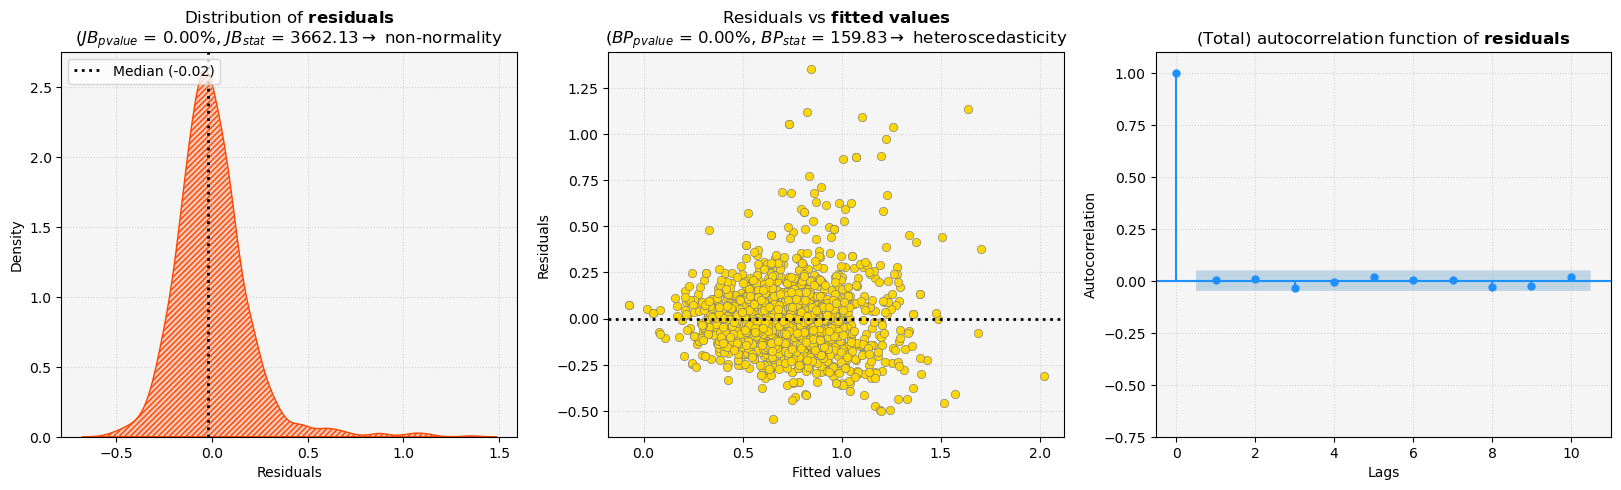

In [13]:
# layout
ncols = 3
nrows = 1
fig, axes = plt.subplots(
    nrows = nrows,
    ncols = ncols,
    figsize=(20, nrows * 5)
)


# distribuzione dei residui
sns.kdeplot(
    x = mhat_kd.resid,
    color = "orangered",
    fill = True,
    hatch = "//////",
    ax = axes[0]
)
median_i = pl.Series(mhat_kd.resid).median()
axes[0].axvline(
    median_i,
    color = "black",
    ls = ":",
    lw = 2,
    label = f"Median ({median_i:.2f})"
)
axes[0].set(
    xlabel = "Residuals",
    ylabel = "Density",
    facecolor = "whitesmoke"
)
axes[0].grid(
    ls = ":",
    alpha = .5
)
axes[0].legend(
    loc = "upper left"
)

# test di normalità di Jarque-Bera per i residui
jb_stat, jb_pvalue = stats.jarque_bera(mhat_kd.resid)
axes[0].set_title(
    f"Distribution of $\\mathbf{{residuals}}$" + 
    f"\n($JB_{{pvalue}}$ = {jb_pvalue*100:.2f}%, $JB_{{stat}}$ = {jb_stat:.2f}"
    + f"$\\rightarrow$ {'normality' if jb_pvalue > 0.05 else 'non-normality'}",
    fontsize = 12
)

# residui vs valori predetti
sns.scatterplot(
    x = mhat_kd.fittedvalues,
    y = mhat_kd.resid,
    color = "gold",
    edgecolor = "grey",
    ax = axes[1]
)
axes[1].set(
    xlabel = "Fitted values",
    ylabel = "Residuals",
    facecolor = "whitesmoke"
)
axes[1].axhline(
    0,
    color = "black",
    ls = ":",
    lw = 2
)
axes[1].grid(
    ls = ":",
    alpha = .5
)

# test di Breusch-Pagan per l'omocedasticità dei residui
bp_stat, bp_pvalue, _, _ = het_breuschpagan(
    resid = mhat_kd.resid,
    exog_het = mhat_kd.model.exog
)
axes[1].set_title(
    f"Residuals vs $\\mathbf{{fitted \\ values}}$"
    f"\n($BP_{{pvalue}}$ = {bp_pvalue*100:.2f}%, $BP_{{stat}}$ = {bp_stat:.2f}"
    + f"$\\rightarrow$ {'homoscedasticity' if bp_pvalue > 0.05 else 'heteroscedasticity'}",
    fontsize = 12
)

# funzione di autocorrelazione (totale)
plot_acf(
    x = mhat_kd.resid,
    lags = 10,
    bartlett_confint = True,
    color = "dodgerblue",
    vlines_kwargs = {
        "colors": "dodgerblue",
    },
    ax = axes[2]
)
axes[2].set(
    xlabel = "Lags",
    ylabel = "Autocorrelation",
    ylim = (-.75, 1.1),
    facecolor = "whitesmoke"
)
axes[2].grid(
    ls = ":",
    alpha = .5
)
axes[2].set_title(
    f"(Total) autocorrelation function of $\\mathbf{{residuals}}$",
    fontsize = 12
)

# Validazione del modello

In [14]:
print(
    "Linear Regression validation results (KD):\n" + tabulate(
        tabular_data = [
            [
                "R2 (train)", f"{mhat_kd.rsquared:.4f}",
            ],
            [
                "RMSE (train)", f"{np.sqrt(mean_squared_error(train_data['KD'].to_list(), mhat_kd.fittedvalues)):.4f}",
            ],
            [
                "RMSE (test)", f"{np.sqrt(mean_squared_error(test_data['KD'].to_list(), mhat_kd.predict(test_data.to_pandas()))):.4f}",
            ],
            [
                "MAE (train)", f"{mean_absolute_error(train_data['KD'].to_list(), mhat_kd.fittedvalues):.4f}",
            ],
            [
                "MAE (test)", f"{mean_absolute_error(test_data['KD'].to_list(), mhat_kd.predict(test_data.to_pandas())):.4f}",
            ]
        ],
        headers = ["Metric", "Value"],
        tablefmt = "pretty",
        colalign = ["center"] * 2
    )
)

Linear Regression validation results (KD):
+--------------+--------+
|    Metric    | Value  |
+--------------+--------+
|  R2 (train)  | 0.6240 |
| RMSE (train) | 0.9055 |
| RMSE (test)  | 0.9698 |
| MAE (train)  | 0.4933 |
|  MAE (test)  | 0.4895 |
+--------------+--------+


## Usiamo il modello per creare Previsioni

In [16]:
nuovo_dato = pd.DataFrame([{
    'Avg Damage Per Round': 200,
    'Headshot': 0.12,
    'First.Deaths': 10,
    'Role': 'duelist',
    'Enemy Team': 'Paper Rex',
    'Match.Type': 'Grand Final',
    'Defused': 7, # Defusi in difesa
    'Detonation Denied': 1, # Defusati in attacco
    "Player Team": "FNATIC",
    "Defused Failed": 0
}])

prediction = mhat_kd.predict(nuovo_dato)
mae_log = 0.4895

lower_bound_log = prediction[0] - mae_log
upper_bound_log = prediction[0] + mae_log

kd_predicted = np.expm1(prediction[0])
kd_min = np.expm1(lower_bound_log)
kd_max = np.expm1(upper_bound_log)

print(f"Previsione K/D: {kd_predicted:.2f}")
print(f"Intervallo (basato su MAE): da {kd_min:.2f} a {kd_max:.2f}")

Previsione K/D: 1.18
Intervallo (basato su MAE): da 0.33 a 2.55
